In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df=pd.read_csv('mymoviedb.csv',lineterminator = '\n')

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [5]:
df.columns =df.columns.str.lower()

In [6]:
df.columns

Index(['release_date', 'title', 'overview', 'popularity', 'vote_count',
       'vote_average', 'original_language', 'genre', 'poster_url'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,popularity,vote_count,vote_average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [9]:
df['release_date']=pd.to_datetime(df['release_date']).dt.year

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   release_date       9827 non-null   int32  
 1   title              9827 non-null   object 
 2   overview           9827 non-null   object 
 3   popularity         9827 non-null   float64
 4   vote_count         9827 non-null   int64  
 5   vote_average       9827 non-null   float64
 6   original_language  9827 non-null   object 
 7   genre              9827 non-null   object 
 8   poster_url         9827 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(5)
memory usage: 652.7+ KB


In [11]:
df.head()


,release_date,title,overview,popularity,vote_count,vote_average,original_language,genre,poster_url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [12]:
cols = ['overview','original_language','poster_url']

In [13]:
df.drop(cols, axis =1 , inplace=True)


In [14]:
df.columns

Index(['release_date', 'title', 'popularity', 'vote_count', 'vote_average',
       'genre'],
      dtype='object')

In [15]:
df.head()

,release_date,title,popularity,vote_count,vote_average,genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [16]:
def categorize_col(df,col,labels):
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
        ]
    
    df[col] = pd.cut(df[col], edges, labels = labels, duplicates='drop')
    return df

In [17]:
labels = ['not_popular','below_avg','average','popular']

In [18]:
categorize_col(df,'vote_average',labels)

df['vote_average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [19]:
df.head()



,release_date,title,popularity,vote_count,vote_average,genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [20]:
df['vote_average'].value_counts()

vote_average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [21]:
df.isnull().sum()

release_date      0
title             0
popularity        0
vote_count        0
vote_average    100
genre             0
dtype: int64

In [22]:
df.dropna(inplace=True)

In [23]:
df.isna().sum()

release_date    0
title           0
popularity      0
vote_count      0
vote_average    0
genre           0
dtype: int64

In [24]:
df.head()


,release_date,title,popularity,vote_count,vote_average,genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [25]:
df['genre'] = df['genre'].str.split(', ')

In [26]:
df = df.explode('genre').reset_index(drop = True)

In [27]:
df.head()

,release_date,title,popularity,vote_count,vote_average,genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   release_date  25552 non-null  int32   
 1   title         25552 non-null  object  
 2   popularity    25552 non-null  float64 
 3   vote_count    25552 non-null  int64   
 4   vote_average  25552 non-null  category
 5   genre         25552 non-null  object  
dtypes: category(1), float64(1), int32(1), int64(1), object(2)
memory usage: 923.6+ KB


In [29]:
df['genre'] = df['genre'].astype('category')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   release_date  25552 non-null  int32   
 1   title         25552 non-null  object  
 2   popularity    25552 non-null  float64 
 3   vote_count    25552 non-null  int64   
 4   vote_average  25552 non-null  category
 5   genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [31]:
df.nunique()


release_date     100
title           9415
popularity      8088
vote_count      3265
vote_average       4
genre             19
dtype: int64

Data Visualization

In [32]:
sns.set_style('whitegrid')

 what is the most frequent genre of movies released by Netflix

In [33]:
df['genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: genre, dtype: object

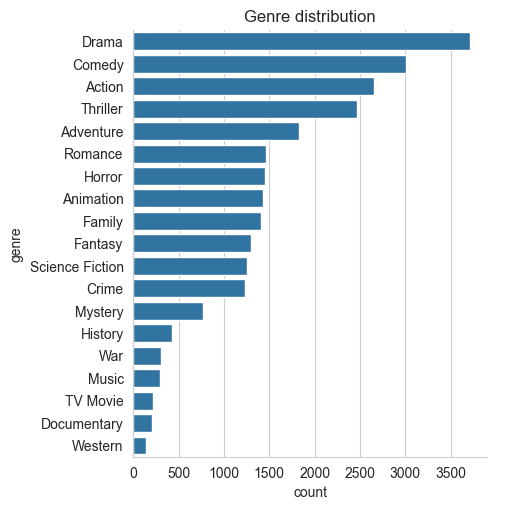

In [37]:
sns.catplot(y='genre',data = df ,kind = 'count',
            order = df['genre'].value_counts().index)
plt.title('Genre distribution')
plt.show()

Which has highest votes in vote average column

In [40]:
df['vote_average'].describe()

count       25552
unique          4
top       average
freq         6613
Name: vote_average, dtype: object

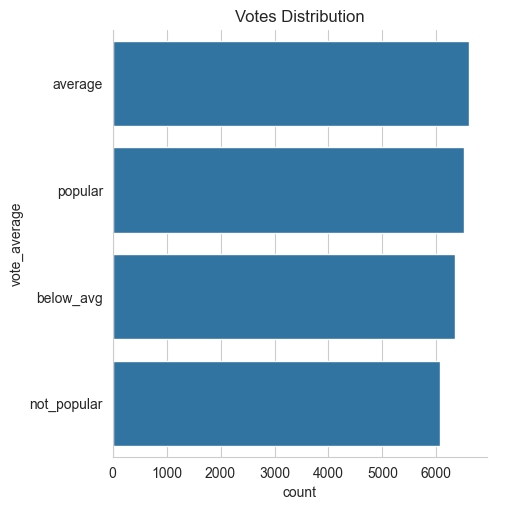

In [41]:
sns.catplot(y='vote_average', data = df, kind = 'count',
            order = df['vote_average'].value_counts().index)
plt.title('Votes Distribution')
plt.show()

Which movie has the highest popularity and what's it genre

In [49]:
df[df['popularity'] == df['popularity'].max()]

,release_date,title,popularity,vote_count,vote_average,genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


Which movie has the lowest popularity and what's it genre

In [48]:
df[df['popularity'] == df['popularity'].min()]

,release_date,title,popularity,vote_count,vote_average,genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


Which year has most filmed movies

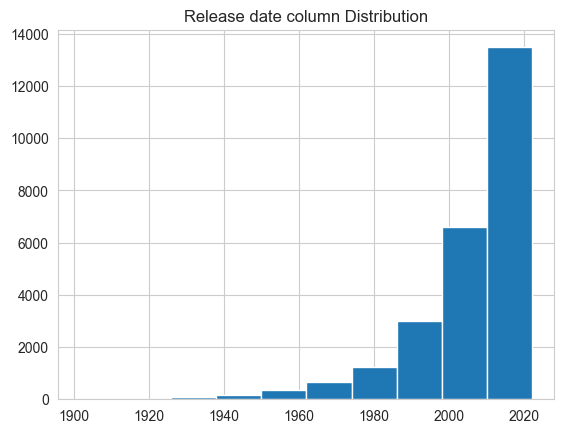

In [54]:
df['release_date'].hist()
plt.title('Release date column Distribution')
plt.show()

📽️ Project Summary: Netflix Movie Database — Exploratory Data Analysis
Overview
This project is an Exploratory Data Analysis (EDA) of a Netflix movie dataset sourced from TMDB (The Movie Database). The dataset contains 9,827 movie records spanning releases from 1902 to 2024, with 9 attributes including title, genre, popularity score, vote count, vote average, release date, original language, and poster URL.

Objectives
The analysis was driven by four key business questions:

What is the most frequently occurring genre on Netflix?
How are movies distributed across vote average categories?
Which movie holds the highest and lowest popularity scores, and what genre does it belong to?
Which year saw the most movie releases?


Data Preprocessing & Cleaning
The notebook follows a structured cleaning pipeline:

Standardized column names to lowercase for consistency.
Converted release dates from full timestamps to release year (integer) for temporal analysis.
Dropped irrelevant columns — overview, original_language, and poster_url — to streamline the dataset.
Handled missing values by detecting and dropping null rows.
Checked for duplicates to ensure data integrity.
Exploded multi-genre entries — since movies can belong to multiple genres (e.g., "Action, Adventure, Thriller"), each genre was split and expanded into individual rows, enabling accurate genre-level analysis.
Encoded genre as a categorical data type for memory efficiency.
Binned the vote_average column into four ordinal categories — not_popular, below_avg, average, and popular — using quartile-based segmentation.


Visualizations
The project used Seaborn and Matplotlib to generate:

A count plot of genre distribution to identify the most common genres.
A vote average distribution chart showing how movies are spread across rating categories.
A release year histogram to uncover temporal trends in movie production.


Tools & Libraries
ToolPurposepandasData loading, cleaning, transformationnumpyNumerical operationsmatplotlibBase plottingseabornStatistical visualizations